In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patheffects as pe

from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

# =========================
# LOAD CSV
# =========================

CSV_FILE = "results (5).csv"

if not os.path.exists(CSV_FILE):
    csv_files = glob.glob("*.csv")
    if not csv_files:
        raise FileNotFoundError("No CSV file was found in the notebook folder.")
    CSV_FILE = csv_files[0]

df = pd.read_csv(CSV_FILE)
df.columns = [c.strip() for c in df.columns]

print("File loaded:", CSV_FILE)
print("Columns found:")
print(df.columns.tolist())

# =========================
# CONVERT TIMESTAMP
# =========================

ts_numeric = pd.to_numeric(df["timestamp"], errors="coerce")

if ts_numeric.notna().sum() > 0:
    if ts_numeric.max() > 10**12:
        df["datetime"] = pd.to_datetime(ts_numeric, unit="ms", errors="coerce")
    elif ts_numeric.max() > 10**9:
        df["datetime"] = pd.to_datetime(ts_numeric, unit="s", errors="coerce")
    else:
        df["datetime"] = pd.to_datetime(df["timestamp"], errors="coerce")
else:
    df["datetime"] = pd.to_datetime(df["timestamp"], errors="coerce")

df = df.dropna(subset=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

# =========================
# CONVERT NUMERIC COLUMNS
# =========================

numeric_columns = ["temperature", "humidity", "speed", "tempThreshold"]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# CONVERT AUTOMODE
# =========================

df["autoMode"] = (
    df["autoMode"]
    .astype(str)
    .str.lower()
    .str.strip()
    .isin(["true", "1", "yes", "si", "sí"])
)

df["is_on"] = df["speed"].fillna(0) > 0
df["mode_label"] = np.where(df["autoMode"], "Automatic", "Manual")

# =========================
# GENERAL VARIABLES
# =========================

device_name = df["thing_name"].mode().iloc[0] if "thing_name" in df.columns else "IoT Fan"

last_temp = df["temperature"].dropna().iloc[-1]
last_hum = df["humidity"].dropna().iloc[-1]
last_speed = df["speed"].dropna().iloc[-1]
last_threshold = df["tempThreshold"].dropna().iloc[-1]
last_mode = df["autoMode"].iloc[-1]

avg_temp = df["temperature"].mean()
max_temp = df["temperature"].max()
min_temp = df["temperature"].min()
avg_hum = df["humidity"].mean()

# =========================
# RUN TIME (FAN ON)
# =========================

# Work with a writable NumPy array to avoid SettingWithCopyWarning on datetime-derived Series
deltas = df["datetime"].diff().shift(-1).dt.total_seconds().to_numpy(copy=True)

positive = deltas[deltas > 0]
median_delta = np.median(positive) if positive.size > 0 else 0.0

# Assume the last sample lasted as long as the typical interval
deltas[-1] = median_delta
deltas = np.nan_to_num(deltas, nan=0.0)
deltas = np.clip(deltas, 0, None)

total_on_seconds = (deltas * df["is_on"].to_numpy()).sum()

def format_duration(seconds):
    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60

    if h > 0:
        return f"{h}h {m}m"
    return f"{m}m"

total_on_text = format_duration(total_on_seconds)

activations = (
    (df["is_on"] == True)
    & (df["is_on"].shift(fill_value=False) == False)
).sum()

display(df.head())

File loaded: results (5).csv
Columns found:
['thing_name', 'timestamp', 'autoMode', 'humidity', 'speed', 'temperature', 'tempThreshold']


,thing_name,timestamp,autoMode,humidity,speed,temperature,tempThreshold,datetime,is_on,mode_label
0,Esp32Ventilador,1780960384407,False,23,25,26.2,30,2026-06-08 23:13:04.407,True,Manual
1,Esp32Ventilador,1780960388402,False,23,75,26.2,30,2026-06-08 23:13:08.402,True,Manual
2,Esp32Ventilador,1780960396437,False,21,0,26.2,30,2026-06-08 23:13:16.437,False,Manual
3,Esp32Ventilador,1780960612811,False,24,0,26.2,30,2026-06-08 23:16:52.811,False,Manual
4,Esp32Ventilador,1780960628836,False,21,0,26.2,30,2026-06-08 23:17:08.836,False,Manual


In [5]:
# =========================
# GENERAL STYLE
# =========================

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

BG = "#F5F8FF"
CARD = "#FFFFFF"
BORDER = "#DDE5F3"
GRID = "#D7DEEA"

NAVY = "#071A44"
TEXT = "#25314D"
MUTED = "#667085"

RED = "#FF2D3D"
BLUE = "#115DFC"
GREEN = "#16A34A"
PURPLE = "#6D28D9"
ORANGE = "#F97316"
GRAY = "#94A3B8"

def add_card_background(fig, ax):
    bbox = ax.get_position()

    card = FancyBboxPatch(
        (bbox.x0 - 0.01, bbox.y0 - 0.015),
        bbox.width + 0.02,
        bbox.height + 0.03,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        transform=fig.transFigure,
        facecolor=CARD,
        edgecolor=BORDER,
        linewidth=1.0,
        zorder=-10
    )

    card.set_path_effects([
        pe.SimplePatchShadow(offset=(2, -2), alpha=0.08),
        pe.Normal()
    ])

    fig.add_artist(card)
    ax.set_facecolor("none")

def style_axis(ax, title, ylabel=None):
    ax.set_title(title, loc="left", color=NAVY, pad=16)

    if ylabel:
        ax.set_ylabel(ylabel, color=TEXT)

    ax.grid(True, axis="y", linestyle="--", linewidth=0.8, color=GRID, alpha=0.9)
    ax.grid(True, axis="x", linestyle="-", linewidth=0.35, color=GRID, alpha=0.45)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(colors=TEXT)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=8))

    return ax

def make_figure(figsize=(13, 5)):
    fig, ax = plt.subplots(figsize=figsize, dpi=140)
    fig.patch.set_facecolor(BG)
    add_card_background(fig, ax)
    return fig, ax

def add_last_value_label(ax, x, y, text, color):
    ax.scatter(
        [x],
        [y],
        s=55,
        color=color,
        edgecolor="white",
        linewidth=1.4,
        zorder=5
    )

    ax.annotate(
        text,
        xy=(x, y),
        xytext=(12, 12),
        textcoords="offset points",
        fontsize=9,
        color=color,
        weight="bold",
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="white",
            ec=color,
            lw=1,
            alpha=0.95
        )
    )

def add_peak_label(ax, x, y, text, color, dy=14):
    """Small marker + label used to highlight min/max points on a series."""
    ax.scatter(
        [x],
        [y],
        s=42,
        color="white",
        edgecolor=color,
        linewidth=1.8,
        zorder=5
    )

    ax.annotate(
        text,
        xy=(x, y),
        xytext=(0, dy),
        textcoords="offset points",
        ha="center",
        fontsize=8.5,
        color=color,
        weight="bold"
    )

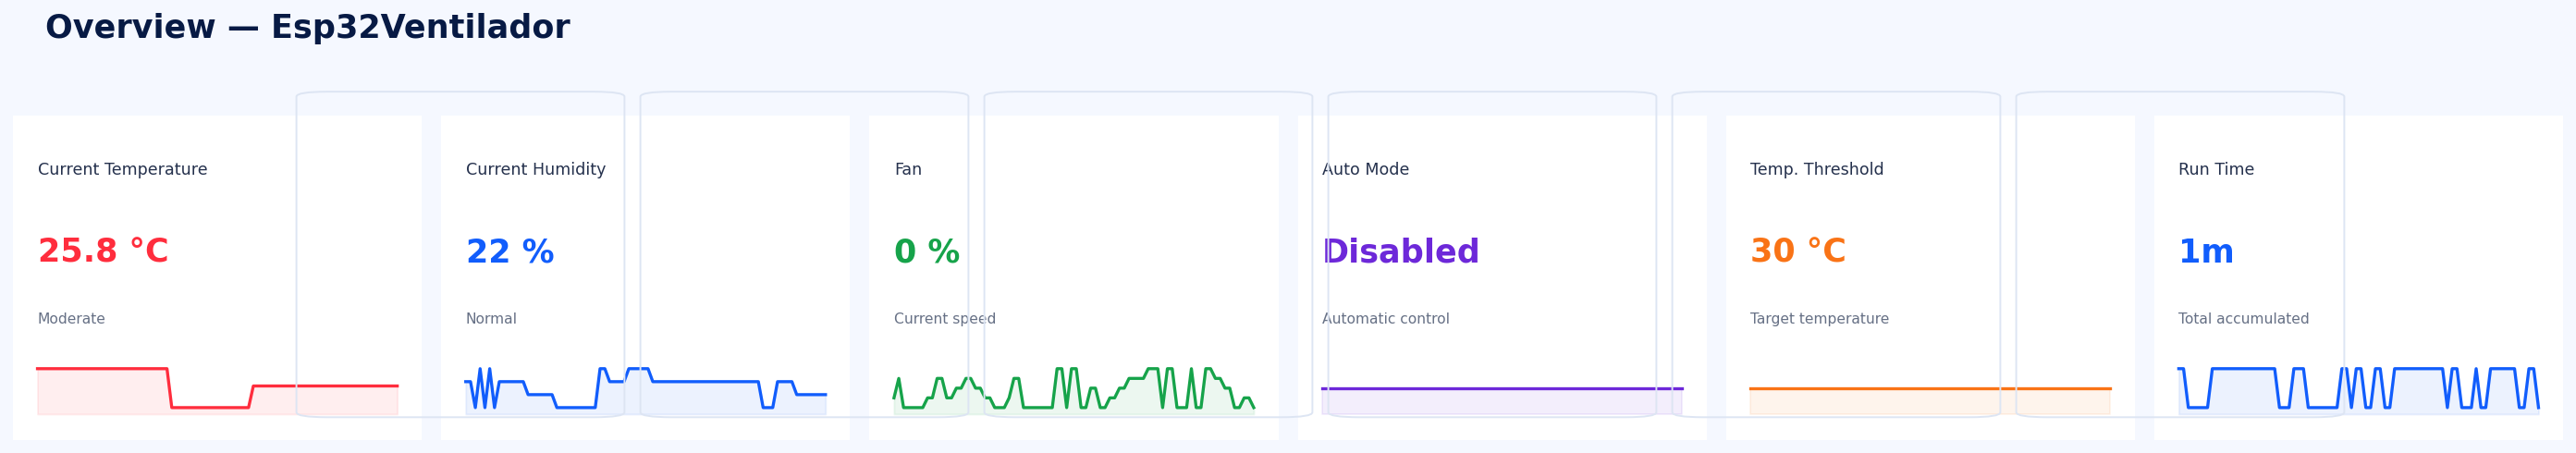

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(20, 3.2), dpi=140)
fig.patch.set_facecolor(BG)

cards = [
    {
        "title": "Current Temperature",
        "value": f"{last_temp:.1f} °C",
        "subtitle": "Moderate" if last_temp < last_threshold else "Above threshold",
        "color": RED,
        "series": df["temperature"]
    },
    {
        "title": "Current Humidity",
        "value": f"{last_hum:.0f} %",
        "subtitle": "Normal",
        "color": BLUE,
        "series": df["humidity"]
    },
    {
        "title": "Fan",
        "value": f"{last_speed:.0f} %",
        "subtitle": "Current speed",
        "color": GREEN,
        "series": df["speed"]
    },
    {
        "title": "Auto Mode",
        "value": "Enabled" if last_mode else "Disabled",
        "subtitle": "Automatic control",
        "color": PURPLE,
        "series": df["autoMode"].astype(int)
    },
    {
        "title": "Temp. Threshold",
        "value": f"{last_threshold:.0f} °C",
        "subtitle": "Target temperature",
        "color": ORANGE,
        "series": df["tempThreshold"]
    },
    {
        "title": "Run Time",
        "value": total_on_text,
        "subtitle": "Total accumulated",
        "color": BLUE,
        "series": df["is_on"].astype(int)
    },
]

for ax, card in zip(axes, cards):
    ax.set_facecolor(CARD)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.06,
        0.82,
        card["title"],
        transform=ax.transAxes,
        fontsize=9,
        color=TEXT,
        weight="medium"
    )

    ax.text(
        0.06,
        0.55,
        card["value"],
        transform=ax.transAxes,
        fontsize=18,
        color=card["color"],
        weight="bold"
    )

    ax.text(
        0.06,
        0.36,
        card["subtitle"],
        transform=ax.transAxes,
        fontsize=8,
        color=MUTED
    )

    y = pd.Series(card["series"]).ffill().bfill().values.astype(float)
    x = np.linspace(0.06, 0.94, len(y))

    if np.nanmax(y) != np.nanmin(y):
        y_scaled = 0.10 + 0.12 * ((y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y)))
    else:
        y_scaled = np.full_like(y, 0.16)

    ax.plot(
        x,
        y_scaled,
        transform=ax.transAxes,
        color=card["color"],
        linewidth=1.7
    )

    ax.fill_between(
        x,
        y_scaled,
        0.08,
        transform=ax.transAxes,
        color=card["color"],
        alpha=0.08
    )

    bbox = ax.get_position()

    border = FancyBboxPatch(
        (bbox.x0, bbox.y0),
        bbox.width,
        bbox.height,
        boxstyle="round,pad=0.008,rounding_size=0.012",
        transform=fig.transFigure,
        facecolor="none",
        edgecolor=BORDER,
        linewidth=1,
        zorder=10
    )

    fig.add_artist(border)

fig.suptitle(
    f"Overview — {device_name}",
    x=0.02,
    y=1.08,
    ha="left",
    fontsize=18,
    fontweight="bold",
    color=NAVY
)

plt.tight_layout()
plt.show()

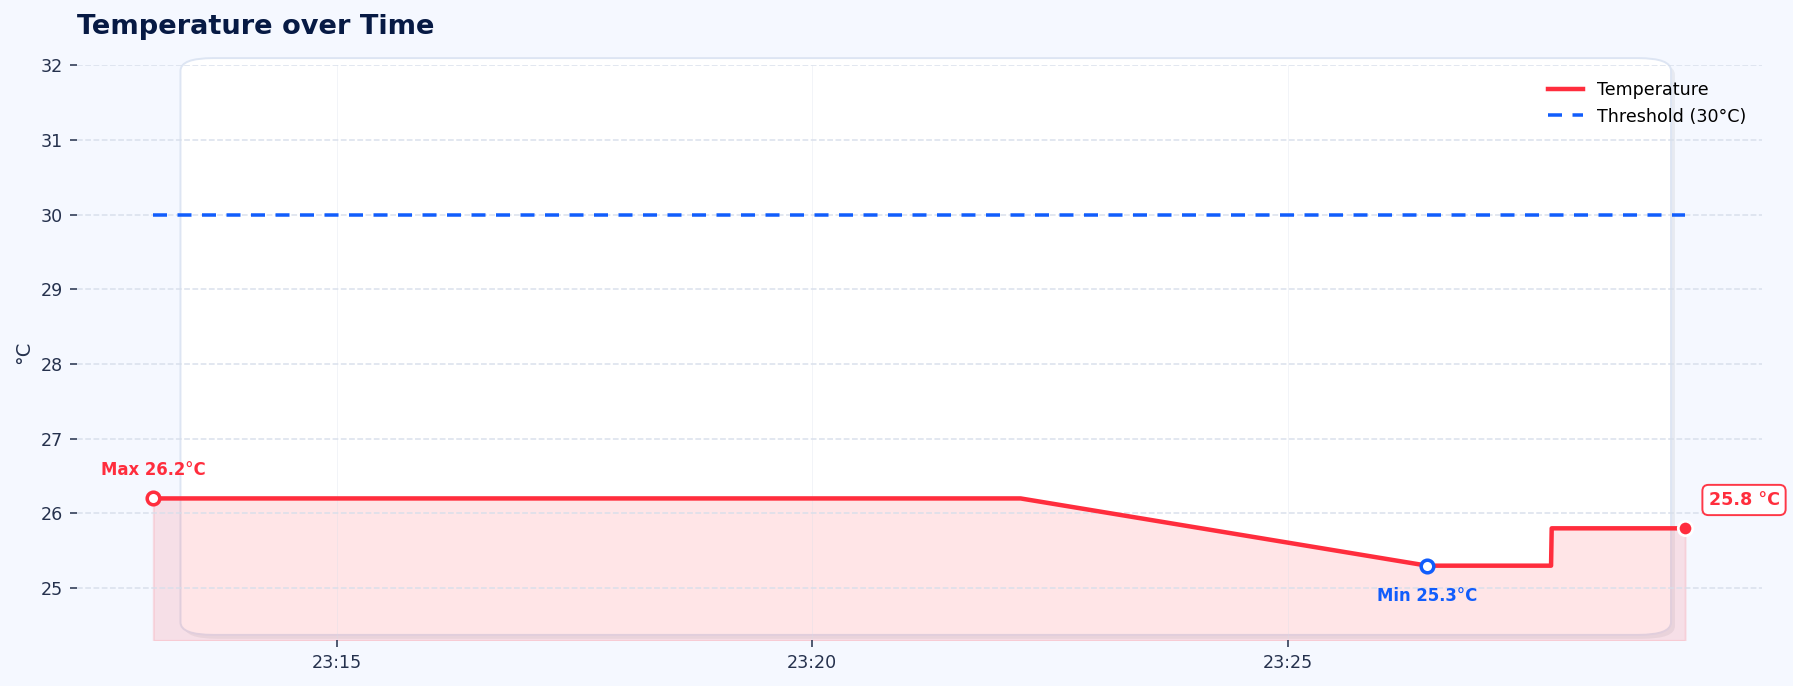

In [8]:
fig, ax = make_figure(figsize=(13, 5))
style_axis(ax, "Temperature over Time", "°C")

x = df["datetime"]
y = df["temperature"]
threshold = df["tempThreshold"]

min_fill = min(y.min(), threshold.min()) - 1

ax.plot(
    x,
    y,
    color=RED,
    linewidth=2.3,
    label="Temperature"
)

ax.fill_between(
    x,
    y,
    min_fill,
    color=RED,
    alpha=0.12
)

ax.plot(
    x,
    threshold,
    color=BLUE,
    linewidth=1.8,
    linestyle=(0, (4, 3)),
    label=f"Threshold ({last_threshold:.0f}°C)"
)

ax.set_ylim(min_fill, max(y.max(), threshold.max()) + 2)

# Highlight the highest and lowest readings
imax = y.idxmax()
imin = y.idxmin()
add_peak_label(ax, x.loc[imax], y.loc[imax], f"Max {y.loc[imax]:.1f}°C", RED, dy=12)
add_peak_label(ax, x.loc[imin], y.loc[imin], f"Min {y.loc[imin]:.1f}°C", BLUE, dy=-18)

add_last_value_label(
    ax,
    x.iloc[-1],
    y.iloc[-1],
    f"{y.iloc[-1]:.1f} °C",
    RED
)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

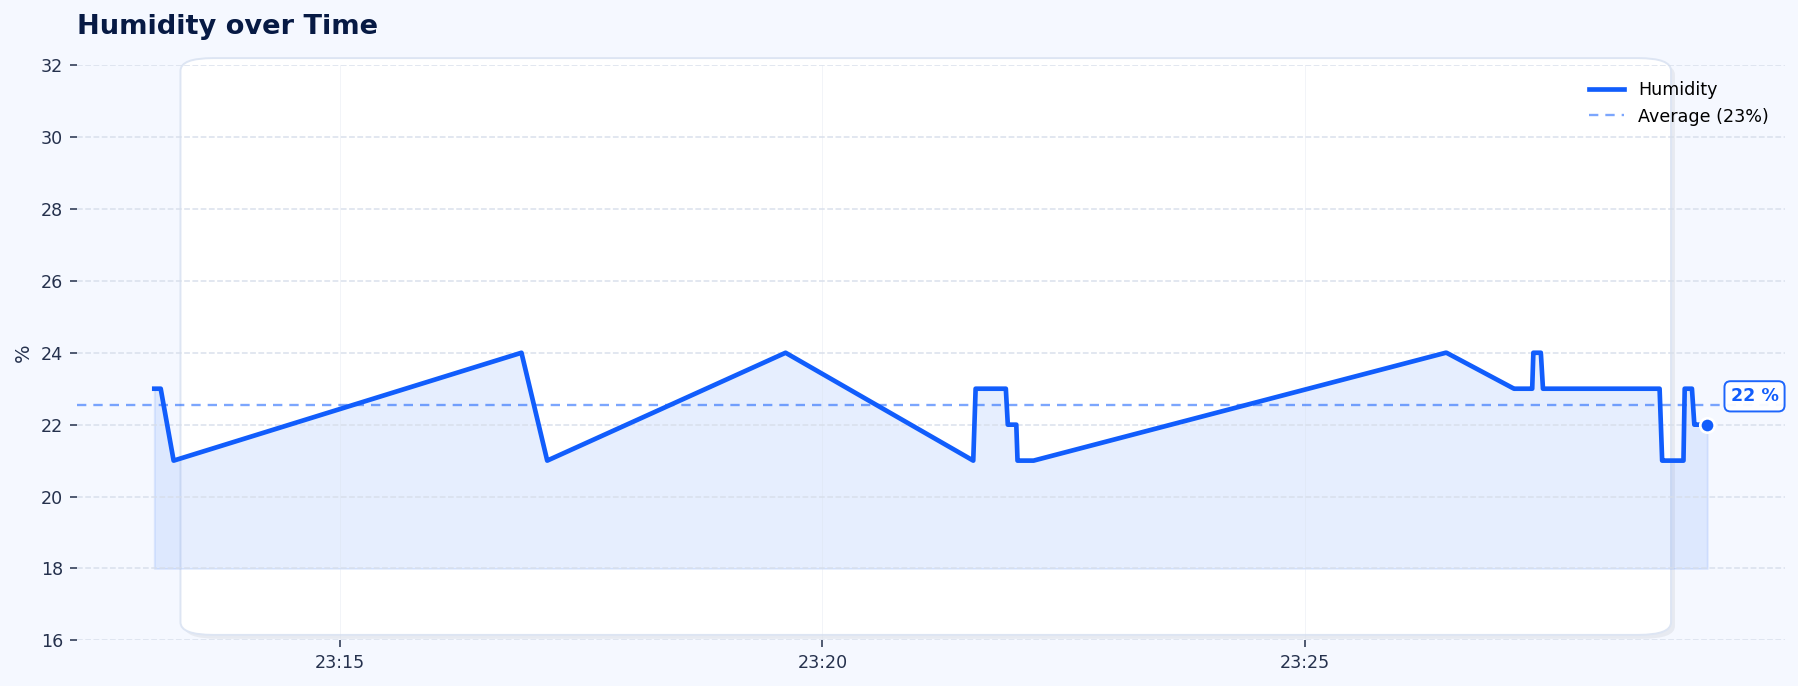

In [9]:
fig, ax = make_figure(figsize=(13, 5))
style_axis(ax, "Humidity over Time", "%")

x = df["datetime"]
y = df["humidity"]

ax.plot(
    x,
    y,
    color=BLUE,
    linewidth=2.4,
    label="Humidity"
)

ax.fill_between(
    x,
    y,
    y.min() - 3,
    color=BLUE,
    alpha=0.10
)

# Average reference line
ax.axhline(
    avg_hum,
    color=BLUE,
    linewidth=1.2,
    linestyle=(0, (4, 3)),
    alpha=0.55,
    label=f"Average ({avg_hum:.0f}%)"
)

ax.set_ylim(max(0, y.min() - 5), min(100, y.max() + 8))

add_last_value_label(
    ax,
    x.iloc[-1],
    y.iloc[-1],
    f"{y.iloc[-1]:.0f} %",
    BLUE
)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

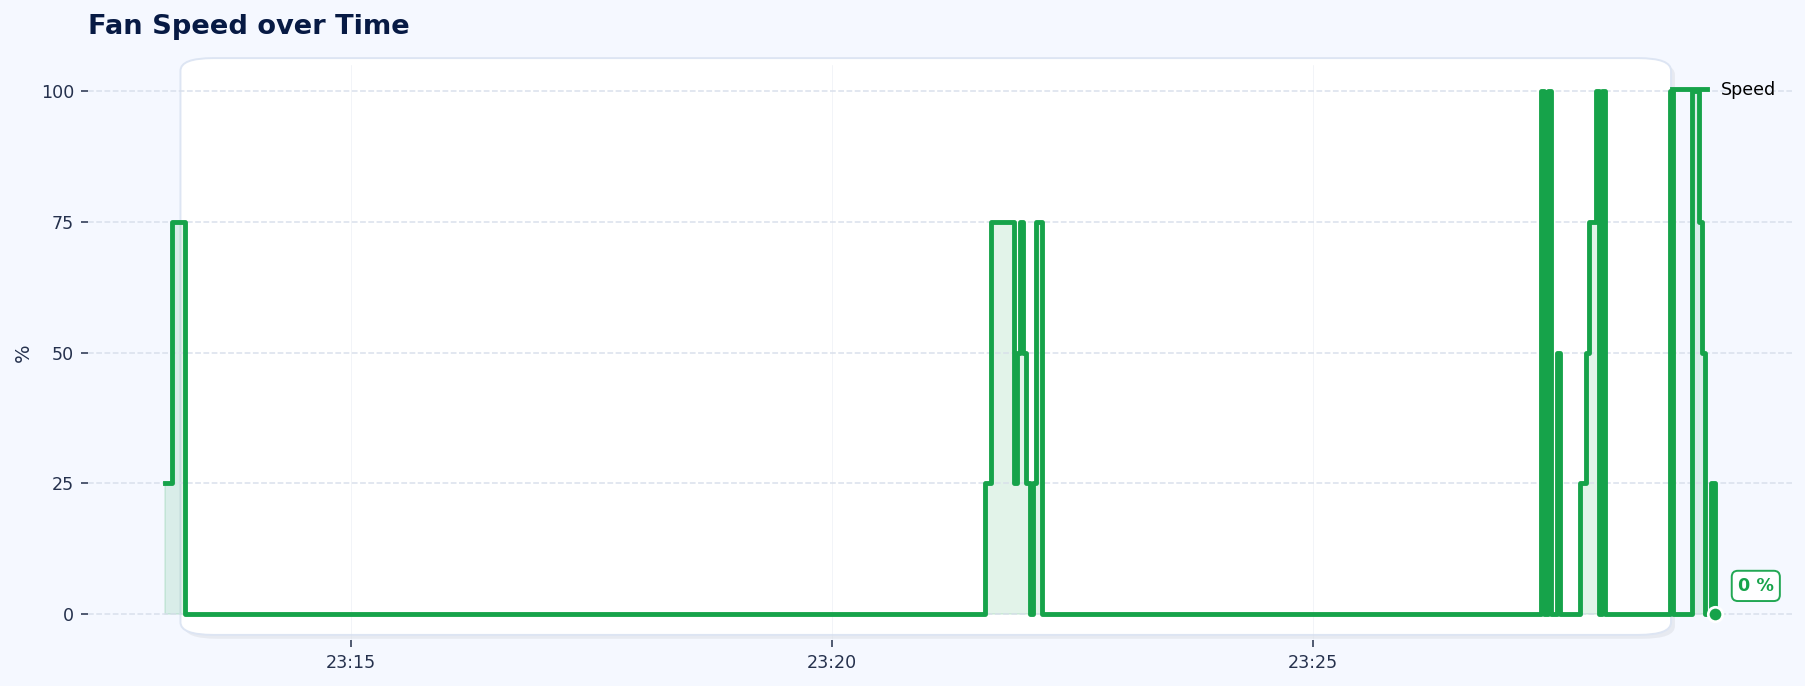

In [10]:
fig, ax = make_figure(figsize=(13, 5))
style_axis(ax, "Fan Speed over Time", "%")

x = df["datetime"]
y = df["speed"]

ax.step(
    x,
    y,
    where="post",
    color=GREEN,
    linewidth=2.5,
    label="Speed"
)

ax.fill_between(
    x,
    y,
    0,
    step="post",
    color=GREEN,
    alpha=0.12
)

ax.set_ylim(-5, 105)
ax.set_yticks([0, 25, 50, 75, 100])

add_last_value_label(
    ax,
    x.iloc[-1],
    y.iloc[-1],
    f"{y.iloc[-1]:.0f} %",
    GREEN
)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

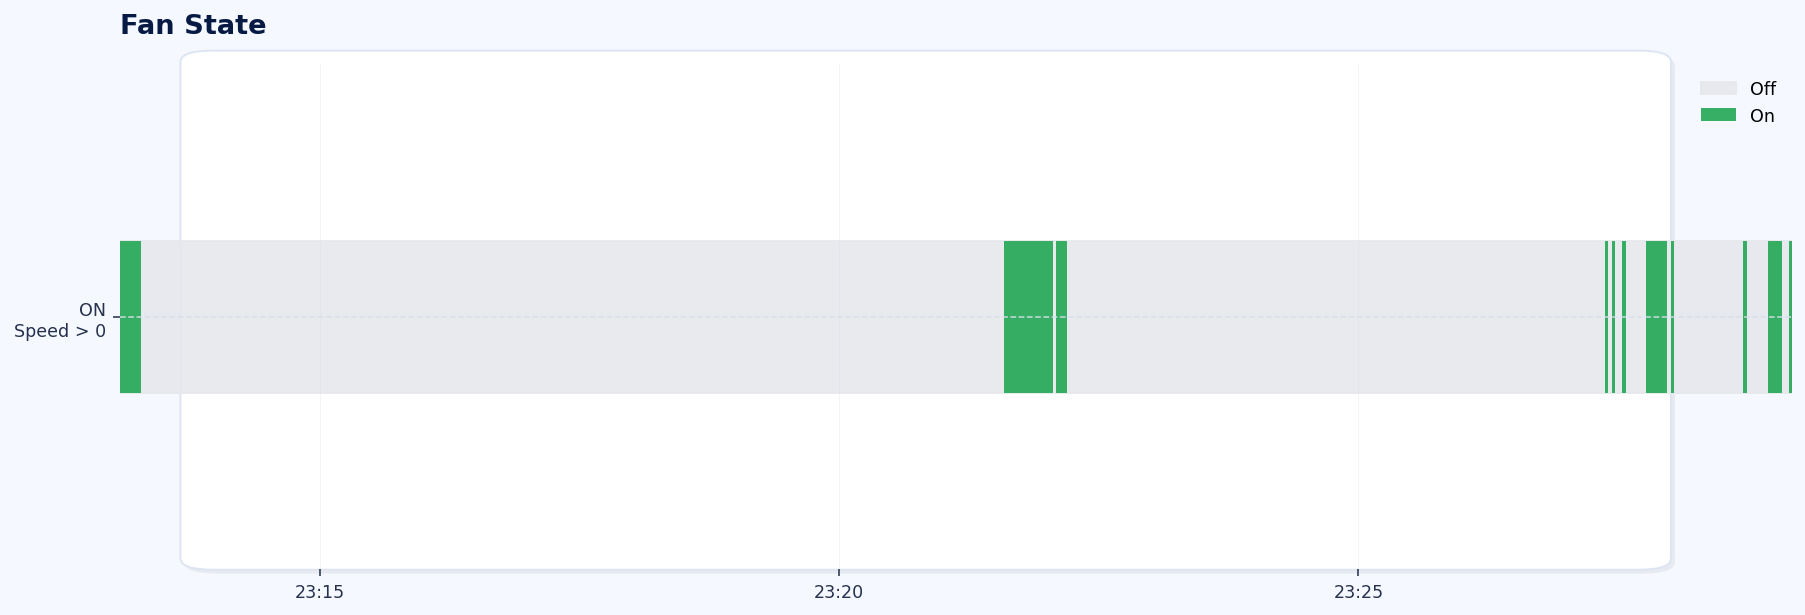

In [12]:
fig, ax = make_figure(figsize=(13, 4.5))
style_axis(ax, "Fan State", "")

start_time = df["datetime"].min()
end_time = df["datetime"].max()

ax.axhspan(
    0.35,
    0.65,
    color="#E5E7EB",
    alpha=0.85,
    label="Off"
)

segments = []
current_start = None

for i in range(len(df)):
    is_on = df.loc[i, "is_on"]
    current_time = df.loc[i, "datetime"]

    if is_on and current_start is None:
        current_start = current_time

    if (not is_on or i == len(df) - 1) and current_start is not None:
        if not is_on:
            current_end = current_time
        else:
            current_end = df.loc[i, "datetime"]

        if current_end > current_start:
            start_num = mdates.date2num(current_start)
            width = mdates.date2num(current_end) - start_num
            segments.append((start_num, width))

        current_start = None

if segments:
    ax.broken_barh(
        segments,
        (0.35, 0.30),
        facecolors=GREEN,
        alpha=0.85,
        label="On"
    )

ax.set_ylim(0, 1)
ax.set_yticks([0.5])
ax.set_yticklabels(["ON\nSpeed > 0"], color=TEXT)

ax.set_xlim(start_time, end_time)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=8))

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

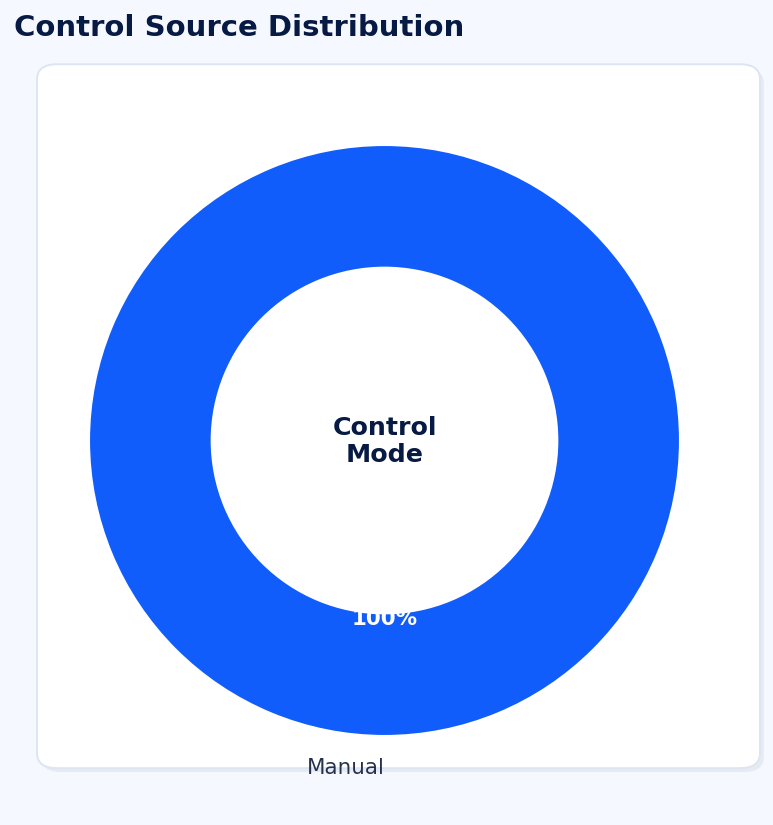

In [13]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=140)
fig.patch.set_facecolor(BG)

dist = df["mode_label"].value_counts()

colors_map = {
    "Automatic": GREEN,
    "Manual": BLUE
}

colors = [colors_map.get(label, ORANGE) for label in dist.index]

wedges, texts, autotexts = ax.pie(
    dist.values,
    labels=dist.index,
    autopct="%1.0f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    textprops=dict(color=TEXT, fontsize=11)
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(11)

ax.text(
    0,
    0,
    "Control\nMode",
    ha="center",
    va="center",
    fontsize=13,
    color=NAVY,
    weight="bold"
)

ax.set_title(
    "Control Source Distribution",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
    pad=18
)

bbox = ax.get_position()

card = FancyBboxPatch(
    (bbox.x0 - 0.02, bbox.y0 - 0.02),
    bbox.width + 0.04,
    bbox.height + 0.04,
    boxstyle="round,pad=0.014,rounding_size=0.018",
    transform=fig.transFigure,
    facecolor=CARD,
    edgecolor=BORDER,
    linewidth=1,
    zorder=-10
)

card.set_path_effects([
    pe.SimplePatchShadow(offset=(2, -2), alpha=0.08),
    pe.Normal()
])

fig.add_artist(card)

plt.tight_layout()
plt.show()

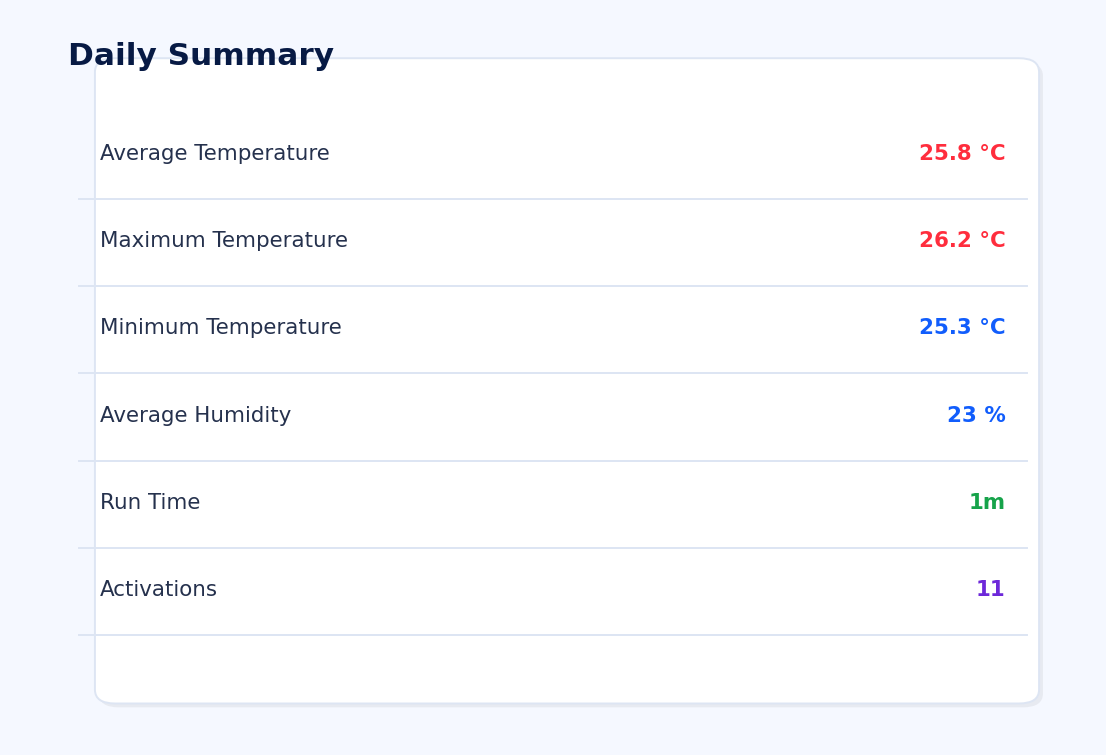

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=140)
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)
ax.axis("off")

summary_rows = [
    ("Average Temperature", f"{avg_temp:.1f} °C", RED),
    ("Maximum Temperature", f"{max_temp:.1f} °C", RED),
    ("Minimum Temperature", f"{min_temp:.1f} °C", BLUE),
    ("Average Humidity", f"{avg_hum:.0f} %", BLUE),
    ("Run Time", total_on_text, GREEN),
    ("Activations", f"{activations}", PURPLE),
]

ax.text(
    0.05,
    0.93,
    "Daily Summary",
    fontsize=16,
    fontweight="bold",
    color=NAVY,
    transform=ax.transAxes
)

y = 0.80

for label, value, color in summary_rows:
    ax.text(
        0.08,
        y,
        label,
        fontsize=11,
        color=TEXT,
        transform=ax.transAxes
    )

    ax.text(
        0.92,
        y,
        value,
        fontsize=11,
        color=color,
        fontweight="bold",
        ha="right",
        transform=ax.transAxes
    )

    ax.plot(
        [0.06, 0.94],
        [y - 0.055, y - 0.055],
        color=BORDER,
        linewidth=1,
        transform=ax.transAxes
    )

    y -= 0.12

bbox = ax.get_position()

card = FancyBboxPatch(
    (bbox.x0 - 0.02, bbox.y0 - 0.02),
    bbox.width + 0.04,
    bbox.height + 0.04,
    boxstyle="round,pad=0.014,rounding_size=0.018",
    transform=fig.transFigure,
    facecolor=CARD,
    edgecolor=BORDER,
    linewidth=1,
    zorder=-10
)

card.set_path_effects([
    pe.SimplePatchShadow(offset=(2, -2), alpha=0.08),
    pe.Normal()
])

fig.add_artist(card)

plt.tight_layout()
plt.show()